# Q3·Q4 추가 EDA — 전압별 용량 변화와 충전 정책

**목적:** 어제의 회귀 설계에 추가할 근거가 있는지 실제 데이터를 확인한다. 기존 `01_EDA.ipynb`는 수정하지 않는다.

- Q3: Cycle 100−10의 ΔQ(V)는 셀 수명에 따라 달라지는가?
- Q4: 충전 정책과 수명은 어떻게 연관되며, 첫 C-rate만으로 설명할 수 있는가?
- Batch 1·2·3 비교는 기술적 EDA다. 모델·피처 선택은 Batch 1 내부에서 수행한다. Batch 2 결과를 이용한 튜닝은 하지 않는다.
- 아래 상관은 인과관계나 모델 성능을 입증하지 않는다. 모든 Batch 1 라벨을 보는 추가 EDA이므로 기존 Hold-out 역시 사전 탐색에서 완전히 격리된 자료는 아니다.


## 목차

- [1. 프로젝트 개요](#section-1)
  - [1-1. 데이터 파일 정보](#section-1_1)
- [2. Q3 — 계산 정의와 원본 검증](#section-2)
  - [2-1. 곡선과 통계값 비교](#section-2_1)
  - [2-2. Q3 결과와 판단](#section-2_2)
- [3. Q4 — 충전 정책과 수명](#section-3)
  - [3-1. 실제 전류 패턴 대조](#section-3_1)
  - [3-2. Q4 결과와 판단](#section-3_2)
- [4. 채택 판단과 다음 단계](#section-4)

<a id="section-1"></a>

## 1. 프로젝트 개요

Q3·Q4를 독립적으로 검토한 기록이다. 통합 EDA는 `01_EDA.ipynb`, 실제 모델 비교와 평가는 `02_Modeling.ipynb`를 기준으로 한다.

<a id="section-1_1"></a>

### 1-1. 데이터 파일 정보

Batch 1: `2017-05-12`, Batch 2: `2018-02-20`, Batch 3: `2018-04-12`의 기존 `.mat` 파일을 사용한다. 초기 관측과 충전 정책을 비교하며 공식 후속 파일은 사용하지 않는다.

In [16]:
from pathlib import Path
import sys, re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
assert (ROOT / "src/preprocess.py").exists(), "프로젝트 루트 또는 notebooks에서 실행하세요."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.preprocess import load_batch_summary

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "AppleGothic" if sys.platform == "darwin" else "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_rows", 90)
FILES = {
    "Batch1": ROOT / "data/2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "Batch2": ROOT / "data/2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch3": ROOT / "data/2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}
OUT = ROOT / "results/q3_q4"
OUT.mkdir(parents=True, exist_ok=True)
summaries = {name: load_batch_summary(path, name) for name, path in FILES.items()}
split = pd.read_csv(ROOT / "results/train_val_split_cells.csv")
train_ids = set(split.loc[split["split"] == "train", "cell_id"])
assert len(train_ids) == 36


<a id="section-2"></a>

## 2. Q3 — 계산 정의와 원본 검증

`ΔQ(V) = Qdlin(Cycle 100) − Qdlin(Cycle 10)`을 동일한 `Vdlin` 위치에서 계산한다. `V`는 원시 시간 기록의 전압이므로 `Qdlin`의 공통 축으로 사용하지 않는다. 이미 보간된 값을 다시 보간하지 않는다.

확인 항목은 사이클 번호 대응, summary와 상세 사이클 수, 상세 Qd 최댓값과 summary 방전용량의 일치, 전압 축 단조성·길이·유한성이다. 분산은 전압 축의 1,000개 값에 대한 `np.var(..., ddof=0)`이며 `log10(분산)`을 후보로 계산한다. 0 또는 비유한 분산은 로그 계산에서 제외하고 사유를 남긴다. 이 값은 전압에 따른 곡선 모양의 변화량이지 물리적 열화 원인 자체는 아니다.

In [17]:
q3_rows, audit_rows, curves = [], [], {}
for batch_name, path in FILES.items():
    with h5py.File(path, "r") as f:
        batch = f["batch"]
        for _, row in summaries[batch_name].iterrows():
            i = int(row["cell_idx"])
            detail = f[batch["cycles"][i, 0]]
            voltage = f[batch["Vdlin"][i, 0]][()].ravel().astype(float)
            positions = [np.flatnonzero(row["cycles"] == cycle) for cycle in (10, 100)]
            reasons = []
            if not all(len(pos) == 1 for pos in positions):
                reasons.append("Cycle 10/100 누락 또는 중복")
            if detail["Qdlin"].shape[0] != len(row["cycles"]):
                reasons.append("summary/상세 사이클 수 불일치")
            if not np.isfinite(voltage).all() or not (np.all(np.diff(voltage) < 0) or np.all(np.diff(voltage) > 0)):
                reasons.append("전압 축 비유한 또는 비단조")
            qs = []
            if not reasons:
                for pos in positions:
                    j = int(pos[0])
                    q = f[detail["Qdlin"][j, 0]][()].ravel().astype(float)
                    raw_q = f[detail["Qd"][j, 0]][()].ravel()
                    if len(q) != len(voltage) or not np.isfinite(q).all():
                        reasons.append("Qdlin 길이/유한성 오류")
                    if not np.isclose(np.max(raw_q), row["QDischarge"][j], atol=1e-6, rtol=0):
                        reasons.append("상세 Qd/summary 값 불일치")
                    qs.append(q)
            variance = np.nan
            if not reasons:
                delta = qs[1] - qs[0]
                variance = float(np.var(delta, ddof=0))
                if not np.isfinite(variance) or variance <= 0:
                    reasons.append("분산 0 또는 비유한")
            passed = not reasons
            audit_rows.append({"batch": batch_name, "cell_id": row["cell_id"],
                "label_valid": bool(np.isfinite(row["cycle_life"]) and row["cycle_life"] > 0),
                "points": len(voltage), "voltage_min": voltage.min(), "voltage_max": voltage.max(),
                "passed": passed, "reason": "; ".join(reasons)})
            if passed:
                curves[row["cell_id"]] = (voltage, delta)
                q3_rows.append({"batch": batch_name, "cell_id": row["cell_id"], "policy": row["policy"],
                    "cycle_life": row["cycle_life"], "delta_q_mean": float(delta.mean()),
                    "delta_q_min": float(delta.min()), "delta_q_var": variance,
                    "delta_q_log_var": np.log10(variance)})
audit = pd.DataFrame(audit_rows)
q3_all = pd.DataFrame(q3_rows)
q3 = q3_all.loc[np.isfinite(q3_all["cycle_life"]) & (q3_all["cycle_life"] > 0)].copy()
audit.to_csv(OUT / "q3_input_audit.csv", index=False)
q3.to_csv(OUT / "q3_cell_features.csv", index=False)
display(audit.groupby("batch").agg(검사_셀수=("cell_id", "size"), 통과_셀수=("passed", "sum"),
    라벨_보유수=("label_valid", "sum"), 포인트수=("points", "min"), 전압_하한=("voltage_min", "min"), 전압_상한=("voltage_max", "max")))
display(audit.loc[~audit["passed"]])
assert len(audit) == 139 and not audit["cell_id"].duplicated().any()
assert len(q3) == 129, "라벨 보유 셀의 계산 가능 수를 확인"
assert np.isfinite(q3["delta_q_log_var"]).all()


,검사_셀수,통과_셀수,라벨_보유수,포인트수,전압_하한,전압_상한
batch,,,,,,
Batch1,46,46,46,1000,2.0000,3.5000
Batch2,47,47,39,1000,2.0000,3.5000
Batch3,46,46,44,1000,2.0000,3.5000


,batch,cell_id,label_valid,points,voltage_min,voltage_max,passed,reason


<a id="section-2_1"></a>

### 2-1. 곡선과 통계값 비교

색은 셀 수명을 나타낸다. 장수명은 >1,000, 단수명은 <500사이클로 기술하되 Batch 1에는 <500 셀이 없어 그 배치 안에서 장·단수명을 직접 비교할 수 없다. 500~1,000은 별도의 중간 구간이며 단수명으로 바꿔 부르지 않는다. 배치별 표본·정책 차이가 있으므로 전체 배치를 합친 상관만으로 후보를 선택하지 않는다.

/var/folders/gq/d77743ts4tq8208b52yk916c0000gn/T/ipykernel_14754/2621458519.py:12: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.savefig(OUT / "q3_delta_q_curves.png", dpi=160, bbox_inches="tight")
/Users/skala_yh/DS_miniproject/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


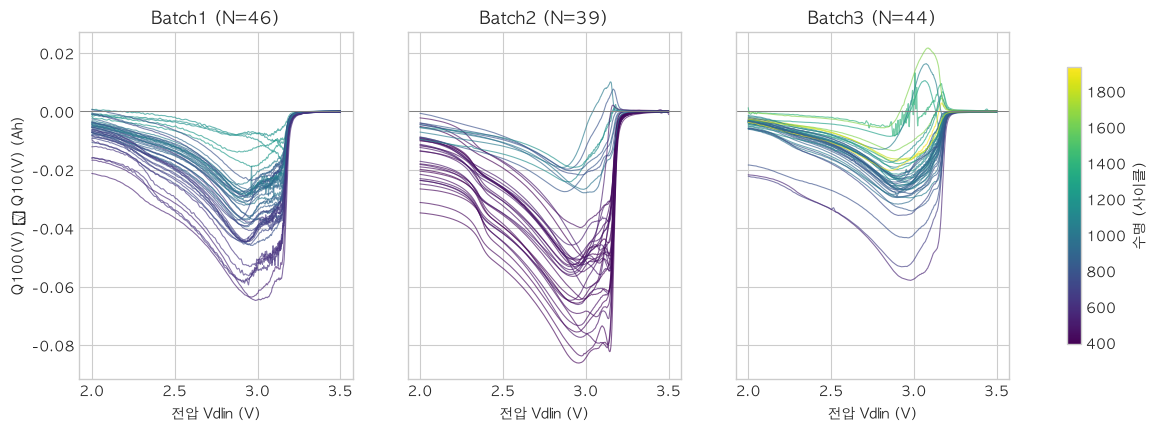

count  median     min     max
batch  수명 구간                                  
Batch1 500~1000     36 -3.7865 -4.1469 -3.3503
       >1000        10 -4.3107 -5.0149 -3.9387
Batch2 500~1000      8 -4.1533 -4.3645 -3.5089
       <500         28 -3.4461 -3.7073 -3.0859
       >1000         3 -4.2718 -4.4486 -4.2316
Batch3 500~1000     21 -4.0918 -4.2951 -3.4517
       >1000        23 -4.3167 -5.0989 -3.9823

,batch,feature,n,Pearson,Spearman
0,Batch1,delta_q_mean,46,0.8538,0.8281
1,Batch1,delta_q_min,46,0.8816,0.8500
2,Batch1,delta_q_log_var,46,-0.8861,-0.8712
3,Batch2,delta_q_mean,39,0.7671,0.6972
4,Batch2,delta_q_min,39,0.8185,0.6609
5,Batch2,delta_q_log_var,39,-0.9019,-0.7090
6,Batch3,delta_q_mean,44,0.6391,0.7561
7,Batch3,delta_q_min,44,0.6921,0.7760
8,Batch3,delta_q_log_var,44,-0.7019,-0.7972


Batch 1 Train 36셀만의 참고 상관


,batch,feature,n,Pearson,Spearman
0,Batch1,delta_q_log_var,36,-0.8717,-0.8388


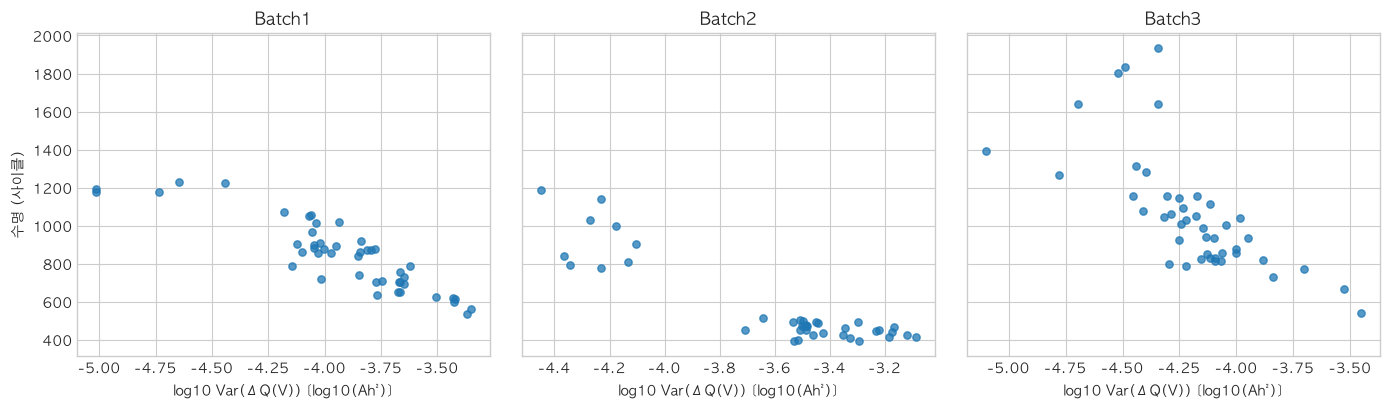

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
norm = plt.Normalize(q3["cycle_life"].min(), q3["cycle_life"].max())
for ax, batch_name in zip(axes, FILES):
    part = q3[q3["batch"] == batch_name]
    for _, row in part.iterrows():
        v, delta = curves[row["cell_id"]]
        ax.plot(v, delta, color=plt.cm.viridis(norm(row["cycle_life"])), alpha=.65, linewidth=.8)
    ax.axhline(0, color="gray", linewidth=.7)
    ax.set(title=f"{batch_name} (N={len(part)})", xlabel="전압 Vdlin (V)")
axes[0].set_ylabel("Q100(V) − Q10(V) (Ah)")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axes, label="수명 (사이클)", shrink=.8)
fig.savefig(OUT / "q3_delta_q_curves.png", dpi=160, bbox_inches="tight")
plt.show()

q3["수명 구간"] = np.select([q3.cycle_life < 500, q3.cycle_life > 1000], ["<500", ">1000"], default="500~1000")
display(q3.groupby(["batch", "수명 구간"], observed=True)["delta_q_log_var"].agg(["count", "median", "min", "max"]).round(4))

def correlation_table(df, features):
    rows = []
    for batch_name, part in df.groupby("batch"):
        for feature in features:
            pair = part[[feature, "cycle_life"]].dropna()
            rows.append({"batch": batch_name, "feature": feature, "n": len(pair),
                "Pearson": pair[feature].corr(pair["cycle_life"]),
                "Spearman": pair[feature].corr(pair["cycle_life"], method="spearman")})
    return pd.DataFrame(rows)
q3_corr = correlation_table(q3, ["delta_q_mean", "delta_q_min", "delta_q_log_var"])
display(q3_corr.round(4))
q3_corr.to_csv(OUT / "q3_correlations.csv", index=False)
print("Batch 1 Train 36셀만의 참고 상관")
display(correlation_table(q3[q3.cell_id.isin(train_ids)], ["delta_q_log_var"]).round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, batch_name in zip(axes, FILES):
    part = q3[q3.batch == batch_name]
    ax.scatter(part.delta_q_log_var, part.cycle_life, alpha=.75, s=28)
    ax.set(title=batch_name, xlabel="log10 Var(ΔQ(V)) [log10(Ah²)]")
axes[0].set_ylabel("수명 (사이클)")
fig.tight_layout()
fig.savefig(OUT / "q3_log_variance_vs_life.png", dpi=160)
plt.show()


,batch,n,동일정책내_Pearson
0,Batch1,45,-0.0719
1,Batch2,39,-0.1967
2,Batch3,44,-0.3696


,delta_q_log_var,delta_q_mean,delta_q_min
delta_q_log_var,1.0000,-0.9262,-0.9470
delta_q_mean,-0.9262,1.0000,0.9925
delta_q_min,-0.9470,0.9925,1.0000


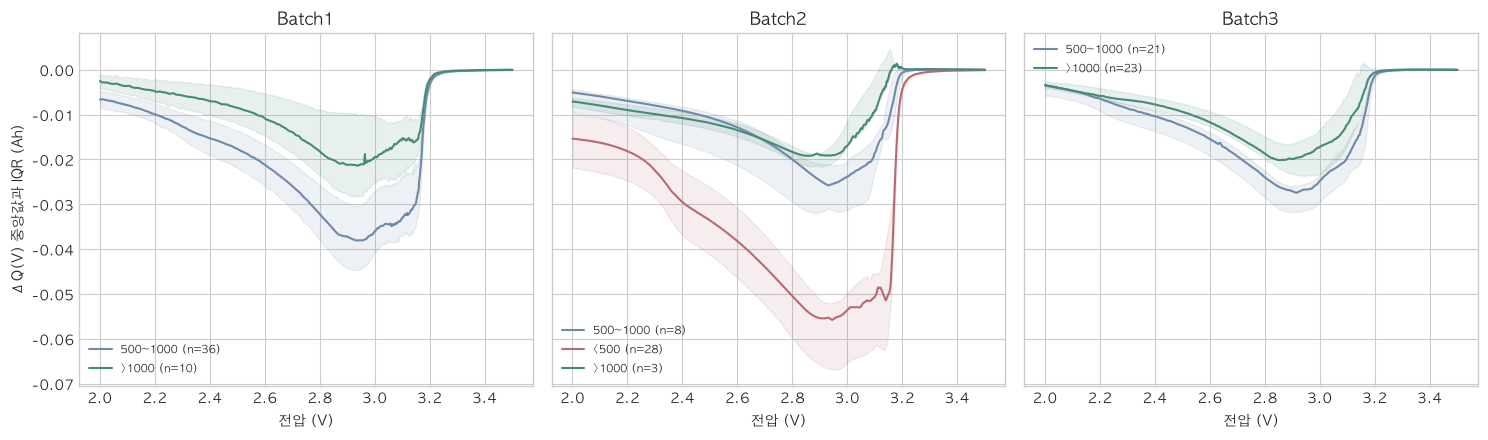

In [19]:
# 동일 정책 내 관계와 후보 간 중복을 추가 점검한다.
within_rows = []
for batch_name, part in q3.groupby("batch"):
    paired = part[part.policy.map(part.policy.value_counts()) >= 2].copy()
    x = paired.delta_q_log_var - paired.groupby("policy").delta_q_log_var.transform("mean")
    y = paired.cycle_life - paired.groupby("policy").cycle_life.transform("mean")
    within_rows.append({"batch": batch_name, "n": len(paired), "동일정책내_Pearson": x.corr(y)})
within = pd.DataFrame(within_rows)
display(within.round(4))
within.to_csv(OUT / "q3_within_policy_correlations.csv", index=False)
display(q3.loc[q3.batch == "Batch1", ["delta_q_log_var", "delta_q_mean", "delta_q_min"]].corr().round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
colors = {"<500": "#b66b74", "500~1000": "#6f89a8", ">1000": "#458a78"}
for ax, batch_name in zip(axes, FILES):
    for group, part in q3[q3.batch == batch_name].groupby("수명 구간"):
        v = curves[part.iloc[0].cell_id][0]
        assert all(np.array_equal(v, curves[cell][0]) for cell in part.cell_id)
        matrix = np.stack([curves[cell][1] for cell in part.cell_id])
        lower, median, upper = np.quantile(matrix, [.25, .5, .75], axis=0)
        ax.plot(v, median, color=colors[group], label=f"{group} (n={len(part)})")
        ax.fill_between(v, lower, upper, color=colors[group], alpha=.12)
    ax.set(title=batch_name, xlabel="전압 (V)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("ΔQ(V) 중앙값과 IQR (Ah)")
fig.tight_layout()
fig.savefig(OUT / "q3_life_group_curves.png", dpi=160)
plt.show()


<a id="section-2_2"></a>

### 2-2. Q3 결과와 판단

**초기 100사이클 안에서도 전압별 용량 곡선의 차이는 관측된다.** 공통 전압 축은 모든 셀에서 1,000포인트, 2.0~3.5V다. 139셀 모두 원본 대응 검사를 통과했고 라벨 보유 129셀의 로그 분산을 계산했다. 그림은 장수명·단수명 구간의 곡선 모양이 다르지만 일부 겹침과 국소적인 요철도 있음을 보여준다. 원본을 임의로 평활화하거나 요철을 오류로 제거하지 않았다.

- 로그 분산과 수명의 Pearson r는 Batch 1 **−0.886**, Batch 2 **−0.902**, Batch 3 **−0.702**다. Batch 1 Train 36셀에서도 **−0.872**다. 곡선 변화의 분산이 큰 셀일수록 수명이 짧은 관계가 관측된다.
- 그러나 동일 정책 평균을 뺀 Batch 1 45셀의 상관은 **−0.072**다. 정책당 대부분 2셀이라 강한 결론은 어렵지만, 전체 관계가 정책 차이를 반영할 가능성이 있다. 정책이 달라진 새 셀에 독립적으로 유용한지는 검증해야 한다.
- Batch 1의 ΔQ 평균·최솟값끼리 r=**0.993**, 로그 분산과 최솟값은 r=**−0.947**이다. 여러 통계값을 모두 넣으면 비슷한 정보를 중복할 수 있다.

**설계 제안:** 로그 분산 하나를 우선 추가 후보로 검토한다. 기존 요약 용량 변화만 보는 것보다 전압별 곡선 변화의 정보를 담을 수 있지만, 실제 개선 여부는 Batch 1 Train 내부 CV에서 비교한다. 이 EDA만으로 최종 피처 채택이나 목표 MAPE 달성을 주장하지 않는다. Batch 1에는 <500 셀이 없으므로 장·단수명 직접 비교를 수행했다고 표현하지 않는다.

<a id="section-3"></a>

## 3. Q4 — 충전 정책과 수명

정책 문자열의 첫 C-rate, 전환 SOC(%), 두 번째 C-rate, `newstructure` 표기를 구분한다. 예를 들어 `5.4C(50%)-3C`의 첫 단계와 `5.4C(80%)-5.4C`는 첫 C-rate가 같아도 전류 패턴이 다르다. 정책별 셀 수·평균·중앙값·범위를 함께 보고, 첫 C-rate만으로 충전 조건 전체를 대표하지 않는다.

열화 관련 보조 자료는 초기 100사이클 내 방전용량 변화와 최고온도다. 초기 용량 증가를 이미 관찰했으므로 이 변화량을 전체 수명의 열화 속도로 해석하지 않는다. 상세 전류는 **A 단위**로 그린다. C-rate로 환산하려면 기준 용량 정의가 필요하다.

In [20]:
policy_pattern = re.compile(r"^(?P<c1>\d+(?:\.\d+)?)C\((?P<soc>\d+(?:\.\d+)?)%\)-(?P<c2>\d+(?:\.\d+)?)C(?P<suffix>.*)$")
q4_rows = []
for batch_name, summary in summaries.items():
    for _, row in summary.iterrows():
        if not np.isfinite(row.cycle_life) or row.cycle_life <= 0:
            continue
        m = policy_pattern.fullmatch(row.policy)
        assert m, f"미해석 정책: {row.policy}"
        positions = [np.flatnonzero(row.cycles == c) for c in (2, 100)]
        assert all(len(pos) == 1 for pos in positions)
        i2, i100 = [int(pos[0]) for pos in positions]
        early = (row.cycles >= 2) & (row.cycles <= 100)
        q4_rows.append({"batch": batch_name, "cell_id": row.cell_id, "policy": row.policy,
            "cycle_life": row.cycle_life, "c1": float(m['c1']), "switch_soc": float(m['soc']),
            "c2": float(m['c2']), "newstructure": 'newstructure' in m['suffix'],
            "delta_q_100_2_mAh": 1000 * (row.QDischarge[i100] - row.QDischarge[i2]),
            "tmax_2_100": float(np.max(row.Tmax[early]))})
q4 = pd.DataFrame(q4_rows)
assert len(q4) == 129 and q4.cell_id.is_unique
q4.to_csv(OUT / "q4_cell_features.csv", index=False)
policy_summary = q4.groupby(["batch", "policy"], sort=True).agg(
    셀수=("cell_id", "size"), 평균수명=("cycle_life", "mean"), 중앙값=("cycle_life", "median"),
    최소수명=("cycle_life", "min"), 최대수명=("cycle_life", "max"),
    초기용량변화_mAh=("delta_q_100_2_mAh", "mean"), 최고온도평균=("tmax_2_100", "mean"))
display(policy_summary.round(3))
policy_summary.to_csv(OUT / "q4_policy_summary.csv")
q4_corr = correlation_table(q4, ["c1", "c2", "switch_soc", "delta_q_100_2_mAh", "tmax_2_100"])
display(q4_corr.round(4))
q4_corr.to_csv(OUT / "q4_correlations.csv", index=False)
print("Batch 1 Train 36셀의 정책 변수 참고 상관")
display(correlation_table(q4[q4.cell_id.isin(train_ids)], ["c1", "c2", "switch_soc"]).round(4))


셀수      평균수명       중앙값      최소수명  \
batch  policy                                                          
Batch1 3.6C(80%)-3.6C                3 1182.0000 1179.0000 1177.0000   
       4.4C(80%)-4.4C                1 1074.0000 1074.0000 1074.0000   
       4.8C(80%)-4.8C                2  753.0000  753.0000  636.0000   
       4C(80%)-4C                    2 1226.5000 1226.5000 1226.0000   
       5.4C(40%)-3.6C                2  966.5000  966.5000  879.0000   
       5.4C(50%)-3.6C                2  899.5000  899.5000  897.0000   
       5.4C(50%)-3C                  2  847.0000  847.0000  788.0000   
       5.4C(60%)-3.6C                2  859.5000  859.5000  857.0000   
       5.4C(60%)-3C                  2  799.5000  799.5000  719.0000   
       5.4C(70%)-3C                  2  739.5000  739.5000  691.0000   
       5.4C(80%)-5.4C                2  546.5000  546.5000  534.0000   
       6C(30%)-3.6C                  2  952.5000  952.5000  891.0000   
       6C(40%)-3.6C                  2  856.0000  856.0000  842.0000   
       6C(40%)-3C                    2  935.5000  935.5000  854.0000   
       6C(50%)-3.6C                  2  792.5000  792.5000  709.0000   
       6C(50%)-3C                    2  888.5000  888.5000  860.0000   
       6C(60%)-3C                    2  744.0000  744.0000  731.0000   
       7C(30%)-3.6C                  2  722.5000  722.5000  703.0000   
       7C(40%)-3.6C                  2  621.0000  621.0000  617.0000   
       7C(40%)-3C                    2  676.0000  676.0000  648.0000   
       8C(15%)-3.6C                  2 1008.5000 1008.5000  966.0000   
       8C(25%)-3.6C                  2  676.5000  676.5000  651.0000   
       8C(35%)-3.6C                  2  607.5000  607.5000  599.0000   
Batch2 3.6C(30%)-6C                  2  421.0000  421.0000  416.0000   
       3.6C(9%)-5C                   2  394.5000  394.5000  393.0000   
       4.65C(44%)-5C                 2  482.5000  482.5000  466.0000   
       4.65C(69%)-6C                 2  452.0000  452.0000  444.0000   
       4.8C(80%)-4.8C                5  483.6000  492.0000  437.0000   
       4.8C(80%)-4.8C-newstructure   3  871.6670  809.0000  777.0000   
       5.2C(50%)-4.25C               5  454.0000  449.0000  424.0000   
       5.2C(58%)-4C                  4  477.7500  483.0000  452.0000   
       5.2C(58%)-4C-newstructure     3  961.6670  904.0000  841.0000   
       5.6C(26%)-4.5C                6  448.5000  446.0000  412.0000   
       5.6C(26%)-4.5C-newstructure   3  991.3330  997.0000  791.0000   
       6C(60%)-3C                    2  400.0000  400.0000  392.0000   
Batch3 3.7C(31%)-5.9C-newstructure   3  660.0000  667.0000  541.0000   
       4.8C(80%)-4.8C-newstructure   6 1564.1670 1640.0000 1078.0000   
       5.3C(54%)-4C-newstructure     8 1074.3750 1051.0000  935.0000   
       5.6C(19%)-4.6C-newstructure   8 1001.3750 1038.0000  796.0000   
       5.6C(36%)-4.3C-newstructure   8  930.8750  890.5000  786.0000   
       5.9C(15%)-4.6C-newstructure   2  867.0000  867.0000  858.0000   
       5.9C(60%)-3.1C-newstructure   2  866.5000  866.5000  731.0000   
       5C(67%)-4C-newstructure       7 1105.7140 1009.0000  813.0000   

                                        최대수명  초기용량변화_mAh  최고온도평균  
batch  policy                                                     
Batch1 3.6C(80%)-3.6C              1190.0000      5.1900 35.2780  
       4.4C(80%)-4.4C              1074.0000      3.6530 34.6550  
       4.8C(80%)-4.8C               870.0000      2.6520 36.2750  
       4C(80%)-4C                  1227.0000      4.6280 33.6720  
       5.4C(40%)-3.6C              1054.0000      4.4090 35.9800  
       5.4C(50%)-3.6C               902.0000      4.1020 37.1240  
       5.4C(50%)-3C                 906.0000      6.2790 37.3720  
       5.4C(60%)-3.6C               862.0000      5.0390 37.3870  
       5.4C(60%)-3C                 880.0000      5.9310 38.1470  
       5.4C(70%)-3C                 788.0000      0.1640 3

,batch,feature,n,Pearson,Spearman
0,Batch1,c1,46,-0.5797,-0.4827
1,Batch1,c2,46,-0.0959,0.0474
2,Batch1,switch_soc,46,0.2346,0.1852
3,Batch1,delta_q_100_2_mAh,46,0.5395,0.5656
4,Batch1,tmax_2_100,46,-0.3998,-0.3224
5,Batch2,c1,39,0.1907,0.0551
6,Batch2,c2,39,-0.1163,-0.1188
7,Batch2,switch_soc,39,0.1161,0.2878
8,Batch2,delta_q_100_2_mAh,39,-0.1993,-0.0967
9,Batch2,tmax_2_100,39,-0.0163,-0.1517


Batch 1 Train 36셀의 정책 변수 참고 상관


,batch,feature,n,Pearson,Spearman
0,Batch1,c1,36,-0.5564,-0.4107
1,Batch1,c2,36,-0.1971,-0.0580
2,Batch1,switch_soc,36,0.1387,0.0856


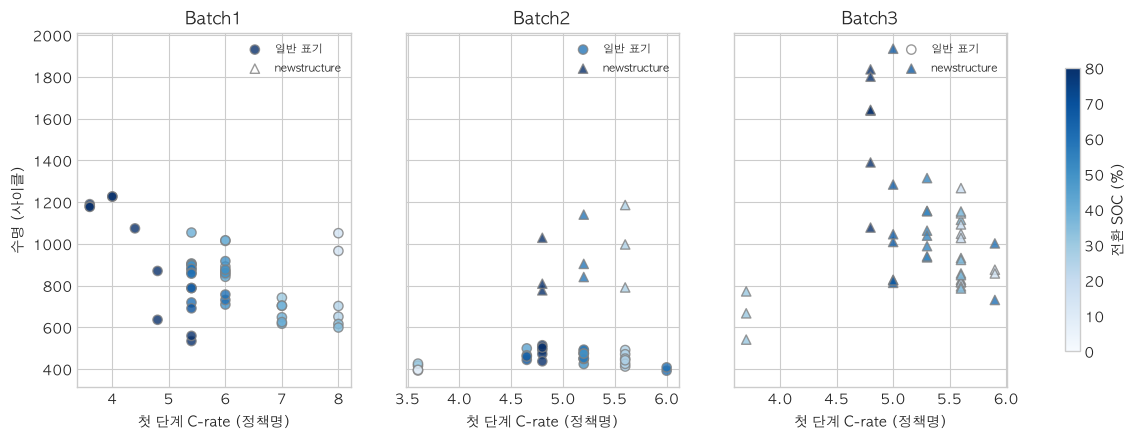

/var/folders/gq/d77743ts4tq8208b52yk916c0000gn/T/ipykernel_14754/4016860584.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False, tick_labels=[f"{policy} (n={len(v)})" for policy, v in zip(order, values)], showfliers=False)


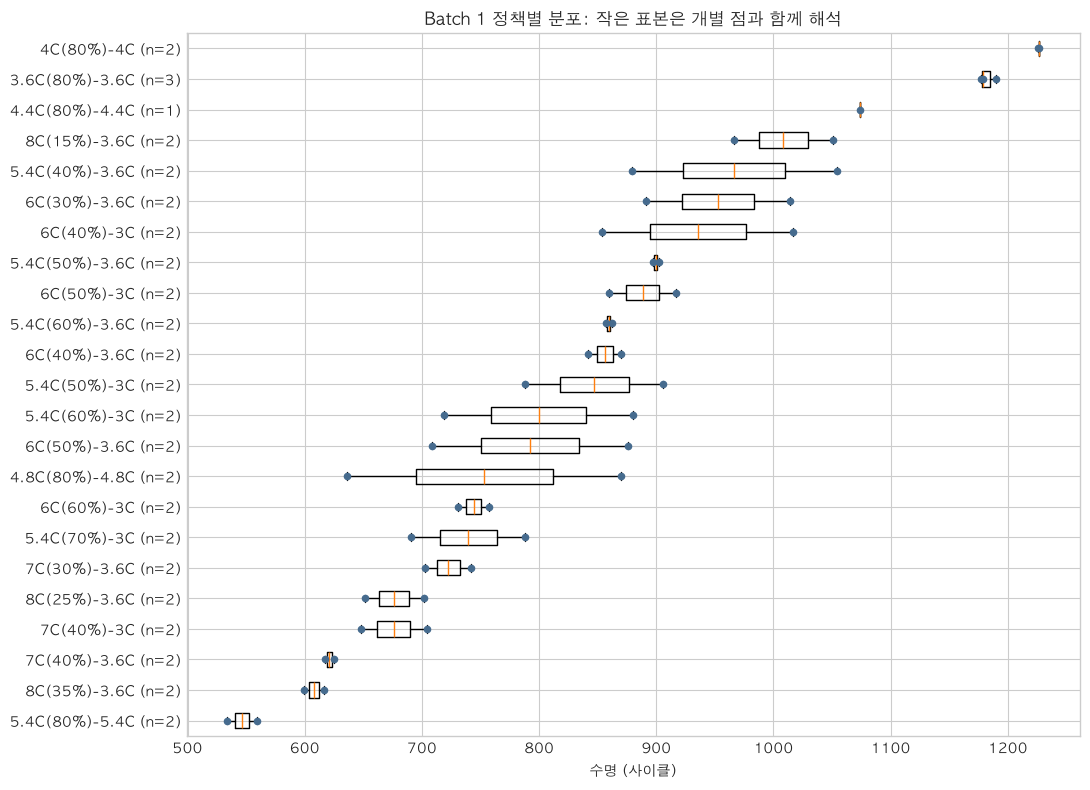

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, batch_name in zip(axes, FILES):
    part = q4[q4.batch == batch_name]
    for flag, marker in [(False, "o"), (True, "^")]:
        sub = part[part.newstructure == flag]
        ax.scatter(sub.c1, sub.cycle_life, c=sub.switch_soc, cmap="Blues", vmin=0, vmax=80,
                   marker=marker, edgecolors="gray", s=45, alpha=.8, label="newstructure" if flag else "일반 표기")
    ax.set(title=batch_name, xlabel="첫 단계 C-rate (정책명)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("수명 (사이클)")
fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(0, 80), cmap="Blues"), ax=axes, label="전환 SOC (%)", shrink=.8)
fig.savefig(OUT / "q4_c1_vs_life.png", dpi=160, bbox_inches="tight")
plt.show()

b1 = q4[q4.batch == "Batch1"]
order = b1.groupby("policy").cycle_life.mean().sort_values().index
fig, ax = plt.subplots(figsize=(11, 8))
values = [b1.loc[b1.policy == policy, "cycle_life"].to_numpy() for policy in order]
ax.boxplot(values, vert=False, tick_labels=[f"{policy} (n={len(v)})" for policy, v in zip(order, values)], showfliers=False)
for y, v in enumerate(values, 1):
    ax.scatter(v, np.full(len(v), y), s=20, color="#466b8e", zorder=3)
ax.set(xlabel="수명 (사이클)", title="Batch 1 정책별 분포: 작은 표본은 개별 점과 함께 해석")
fig.tight_layout()
fig.savefig(OUT / "q4_batch1_policy_distribution.png", dpi=160)
plt.show()


<a id="section-3_1"></a>

### 3-1. 실제 전류 패턴 대조

Batch 1에서 첫 C-rate 최저·중간·최고 셀을 대표 예시로 선택한다. 대표 셀 3개는 전체 정책을 대표하는 통계 표본이 아니다. Cycle 10과 100의 충전 중 전류를 비교하여 정책 문자열이 실제 기록과 어떤 형태로 연결되는지 확인한다. 양수 전류를 충전 구간으로 표시하며 전류 원인을 단정하지 않는다.

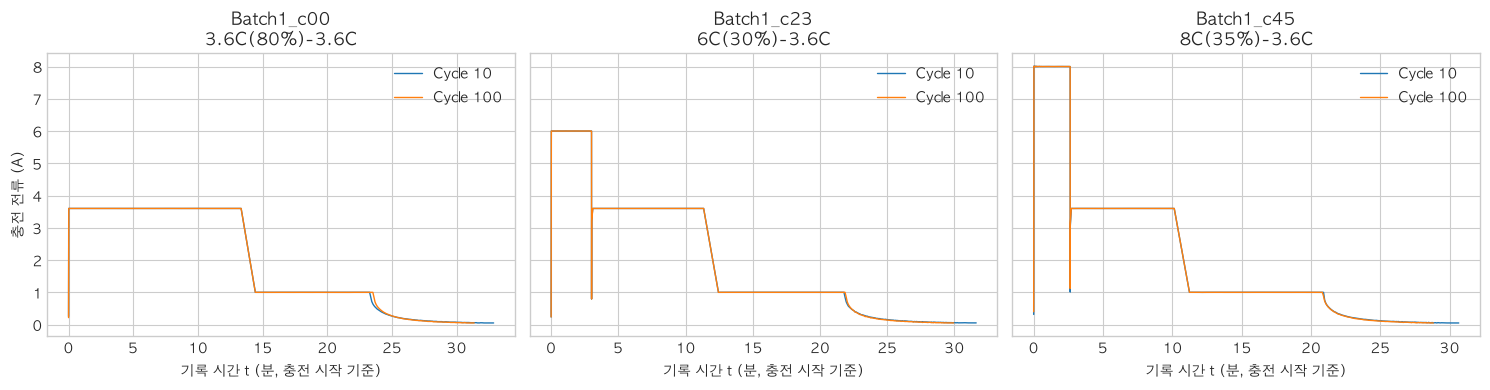

,cell_id,policy,cycle,max_charge_current_A
0,Batch1_c00,3.6C(80%)-3.6C,10,3.6010
1,Batch1_c00,3.6C(80%)-3.6C,100,3.6010
2,Batch1_c23,6C(30%)-3.6C,10,6.0020
3,Batch1_c23,6C(30%)-3.6C,100,6.0020
4,Batch1_c45,8C(35%)-3.6C,10,8.0070
5,Batch1_c45,8C(35%)-3.6C,100,8.0050


In [22]:
ordered = b1.sort_values(["c1", "cell_id"])
selected = ordered.iloc[[0, len(ordered)//2, len(ordered)-1]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
current_rows = []
with h5py.File(FILES["Batch1"], "r") as f:
    for ax, (_, row) in zip(axes, selected.iterrows()):
        source = summaries["Batch1"].loc[summaries["Batch1"].cell_id == row.cell_id].iloc[0]
        detail = f[f["batch"]["cycles"][int(source.cell_idx), 0]]
        for cycle in (10, 100):
            j = int(np.flatnonzero(source.cycles == cycle)[0])
            current = f[detail["I"][j, 0]][()].ravel()
            t = f[detail["t"][j, 0]][()].ravel()
            assert len(t) == len(current) and np.isfinite(t).all() and np.isfinite(current).all()
            charging = current > .05
            ax.plot(t[charging] - t[charging][0], current[charging], label=f"Cycle {cycle}", linewidth=1)
            current_rows.append({"cell_id": row.cell_id, "policy": row.policy, "cycle": cycle,
                                 "max_charge_current_A": float(current[charging].max())})
        ax.set(title=f"{row.cell_id}\n{row.policy}", xlabel="기록 시간 t (분, 충전 시작 기준)")
        ax.legend()
axes[0].set_ylabel("충전 전류 (A)")
fig.tight_layout()
fig.savefig(OUT / "q4_current_profiles.png", dpi=160)
plt.show()
display(pd.DataFrame(current_rows).round(3))


In [23]:
# 같은 첫 C-rate에서도 전체 정책과 수명은 다르다.
display(b1.loc[b1.c1 == 5.4].groupby("policy").cycle_life.agg(["count", "mean", "min", "max"]).round(2))
display(b1.groupby("c1").cycle_life.agg(["count", "mean", "median"]).round(2))
print("Batch 1: C1·초기 용량 변화·온도 관계")
display(b1[["c1", "delta_q_100_2_mAh", "tmax_2_100"]].corr().round(4))
print("Batch 1 정책별 표본 수 분포")
display(b1.policy.value_counts().value_counts().rename_axis("정책당_셀수").rename("정책수").sort_index())


,count,mean,min,max
policy,,,,
5.4C(40%)-3.6C,2,966.5000,879.0000,1054.0000
5.4C(50%)-3.6C,2,899.5000,897.0000,902.0000
5.4C(50%)-3C,2,847.0000,788.0000,906.0000
5.4C(60%)-3.6C,2,859.5000,857.0000,862.0000
5.4C(60%)-3C,2,799.5000,719.0000,880.0000
5.4C(70%)-3C,2,739.5000,691.0000,788.0000
5.4C(80%)-5.4C,2,546.5000,534.0000,559.0000


,count,mean,median
c1,,,
3.6000,3,1182.0000,1179.0000
4.0000,2,1226.5000,1226.5000
4.4000,1,1074.0000,1074.0000
4.8000,2,753.0000,753.0000
5.4000,14,808.2900,859.5000
6.0000,12,861.5000,865.0000
7.0000,6,673.1700,675.5000
8.0000,6,764.1700,676.5000


Batch 1: C1·초기 용량 변화·온도 관계


,c1,delta_q_100_2_mAh,tmax_2_100
c1,1.0000,-0.2202,0.4504
delta_q_100_2_mAh,-0.2202,1.0000,0.0240
tmax_2_100,0.4504,0.0240,1.0000


Batch 1 정책별 표본 수 분포


정책당_셀수
1     1
2    21
3     1
Name: 정책수, dtype: int64

<a id="section-3_2"></a>

### 3-2. Q4 결과와 판단

**Batch 1에서는 첫 C-rate가 높을수록 수명이 짧아지는 전체 관계가 있지만, 모든 배치와 정책에 일률적으로 적용되지는 않는다.** 첫 C-rate와 수명의 Pearson r는 Batch 1 **−0.580**, Batch 2 **+0.191**, Batch 3 **−0.083**이다. 서로 다른 정책 구성과 `newstructure` 조건을 섞어 단순한 원인으로 해석할 수 없다.

- Batch 1에서 첫 단계가 모두 5.4C인 정책도 평균 수명이 **546.5~966.5사이클**로 다르다. 전환 SOC와 두 번째 C-rate까지 충전 조건으로 고려해야 한다.
- 첫 C-rate별 평균도 5.4C **808.3**, 6C **861.5**, 7C **673.2**, 8C **764.2사이클**로 단조 감소하지 않는다. 셀 수와 다른 조건이 달라 직접적인 속도 비교 실험으로 볼 수 없다.
- Batch 1의 첫 C-rate는 초기 최고온도와 r=**0.450**, 초기 용량 변화와 r=**−0.220**이다. 온도 관련 경로를 추가 확인할 단서지만 고속충전이 열화를 유발했다는 인과 증거는 아니다. 초기 용량 변화는 전체 수명의 열화 속도가 아니다.
- Batch 1 23개 정책 중 **21개는 2셀, 1개는 3셀, 1개는 1셀**이다. 박스플롯의 개별 점과 표본 수를 함께 봐야 한다. 대표 3셀의 Cycle 10·100 실제 전류 패턴은 유사하게 이어지지만 전체 셀의 패턴 안정성을 검증한 것은 아니다.

**설계 제안:** `charge_c1_rate` 단독 설명은 보강이 필요하다. 첫 C-rate·두 번째 C-rate·전환 SOC를 각각 검토하되 작은 표본에서 변수를 늘릴 가치는 Batch 1 내부 검증으로 결정한다. `newstructure`를 물리적 구조 변화라고 해석하지 않으며 의미 확인 전 인과 설명에 사용하지 않는다. 정책과 열화 관계를 더 깊게 확인하는 일은 후속 과제로 남길 수 있다.

<a id="section-4"></a>

## 4. 채택 판단과 다음 단계

- **Q3:** 원본 검증을 통과한 ΔQ(V) 로그 분산은 기존 요약 용량 변화와 다른 곡선 정보를 담는 입력 후보다. Batch 1 Train 내부 CV에서 기준 피처에 추가했을 때 MAPE·분할 민감도가 개선되는지 확인한 뒤 채택한다. 현재는 계산 가능성과 관계를 확인한 단계다.
- **Q4:** 첫 C-rate·두 번째 C-rate·전환 SOC는 예측 시점에 알려진 조건 후보다. 첫 C-rate 단독 사용보다 전체 정책의 의미와 소표본을 고려해야 한다. 정책 인코딩은 학습 분할에서만 적합하고 새 정책 처리 규칙을 정한다.
- Batch 2·3의 수명과 상관은 배치별 차이를 설명하는 자료이며 모델 선택 기준으로 사용하지 않는다. Batch 2는 모델 확정 후 평가한다.
- 이 노트북의 결과를 기존 보고서·후보 정의표에 자동으로 반영하지 않는다. 검토 후 채택하면 2일차 구현에 사용하고, 보류하면 기존 설계로 진행한다.